# 45 - Multiclass Metrics and the Confusion Matrix

**Section:** Model Evaluation | **Prereqs:** `Model Evaluation/ARPF_WineDataset.ipynb` | **Next:** `Model Evaluation/CodeChallenge_UnbalncedMNIST.ipynb`

Precision and recall extend to 10 classes by being computed **per class**:
for digit 7, 'positive' means 'is a 7' and everything else is negative. That
gives 10 precisions, 10 recalls, 10 F1s - which is why `average=None` appears in
every call here (it returns the per-class array instead of collapsing it).

**The averaging options, and they matter:**
- `average=None` - the per-class array. Start here.
- `'macro'` - unweighted mean over classes, so a rare class counts as much as a
  common one. The right default on imbalanced data.
- `'weighted'` - weighted by class size. Closer to accuracy, hides rare-class
  failure.
- `'micro'` - pool all predictions; on single-label multiclass this equals
  accuracy exactly.

**The confusion matrix is the real payoff here.** A 10x10 grid, rows = truth,
columns = prediction, diagonal = correct. The bright off-diagonal cells tell you
*which* digits the model confuses - typically 4/9, 3/5, 7/1. That is actionable
in a way a single accuracy number never is.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import TensorDataset,DataLoader

from torchvision.datasets import MNIST
from torchvision.transforms import ToTensor

In [2]:
data = MNIST(
    root='./data',        # Directory to store the dataset
    train=True,           # Load the training set
    download=True,
    transform = ToTensor()
)

test_data =  MNIST(
    root='./data',        # Directory to store the dataset
    train=False,           # Load the training set
    download=True,
    transform = ToTensor()
)

100%|██████████| 9.91M/9.91M [00:01<00:00, 5.73MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 130kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.25MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 10.1MB/s]


In [3]:
# Standard MNIST pipeline: scale, split train/dev, tensors on GPU, loaders.
def makeDataset():

  data_tensor = data.data.view(-1, 784)
  labels_tensor = data.targets


  from sklearn.preprocessing import MinMaxScaler

  scaler = MinMaxScaler()

  data_subset = scaler.fit_transform(data_tensor)


  from sklearn.model_selection import train_test_split

  train_data, dev_data , train_label, dev_label = train_test_split(data_subset, labels_tensor, test_size=0.2, shuffle=True)

  train_data = torch.tensor(train_data, dtype=torch.float, device='cuda')
  train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')


  dev_data = torch.tensor(dev_data, dtype=torch.float, device='cuda')
  dev_label = torch.tensor(dev_label, dtype=torch.long, device='cuda')

  train_tensor = TensorDataset(train_data, train_label)
  dev_tensor = TensorDataset(dev_data,dev_label)

  bs = 32
  data_loader = DataLoader(train_tensor, batch_size=bs, drop_last=True, shuffle=True)
  test_loader = DataLoader(dev_tensor, batch_size=dev_tensor.tensors[0].shape[0])


  return data_loader, test_loader

In [4]:
data_loader, test_loader = makeDataset()

/tmp/ipython-input-1794242417.py:19: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_label = torch.tensor(train_label, dtype=torch.long, device='cuda')
/tmp/ipython-input-1794242417.py:23: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  dev_label = torch.tensor(dev_label, dtype=torch.long, device='cuda')


In [5]:
# 784-64-32-16-10, raw logits.
class model(nn.Module):
  def __init__(self):
    super().__init__()

    self.input_layer = nn.Linear(784, 64)

    self.fc1 = nn.Linear(64,32)

    self.fc2 = nn.Linear(32,16)

    self.output_layer = nn.Linear(16,10)


  def forward(self,x):

    x = F.relu(self.input_layer(x))

    x = F.relu(self.fc1(x))

    x = F.relu(self.fc2(x))

    return self.output_layer(x)

In [6]:
# Standard training function.
def train_model():


  classifier = model().to('cuda')

  epochs = 50
  lr = 0.01

  lossFunc = nn.CrossEntropyLoss()
  optimizer = torch.optim.SGD(classifier.parameters(), lr=lr)

  train_acc = []
  dev_acc = []
  losses = torch.zeros(epochs)


  for i in range(epochs):

    classifier.train()
    batch_acc = []
    batch_loss = []

    for x,y in data_loader:

      yhat = classifier(x)

      loss = lossFunc(yhat,y)
      batch_loss.append(loss.item())


      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

      batch_acc.append(100 * torch.mean( (torch.argmax(yhat,dim = 1) == y).float()).cpu() )

    train_acc.append(np.mean(batch_acc))
    losses[i] = np.mean(batch_loss)

    if i % 10 == 0 or i == epochs-1:
      print(f"Sample Size = {data_loader.dataset.tensors[0].shape[0]} |Epoch {i} : Loss = {losses[i].item()}")

    classifier.eval()
    with torch.no_grad():
      X,Y = next(iter(test_loader))
      Preds = torch.argmax(classifier(X), dim = 1)
      dev_acc.append( 100 * torch.mean( (Preds == Y).float()) )

  print()
  return losses, train_acc, dev_acc, classifier


In [7]:
losses, train_acc, dev_acc, classifier = train_model()

Sample Size = 48000 |Epoch 0 : Loss = 2.1424899101257324
Sample Size = 48000 |Epoch 10 : Loss = 0.1491612046957016
Sample Size = 48000 |Epoch 20 : Loss = 0.07571730017662048
Sample Size = 48000 |Epoch 30 : Loss = 0.04346664994955063
Sample Size = 48000 |Epoch 40 : Loss = 0.025091813877224922
Sample Size = 48000 |Epoch 49 : Loss = 0.01460710633546114



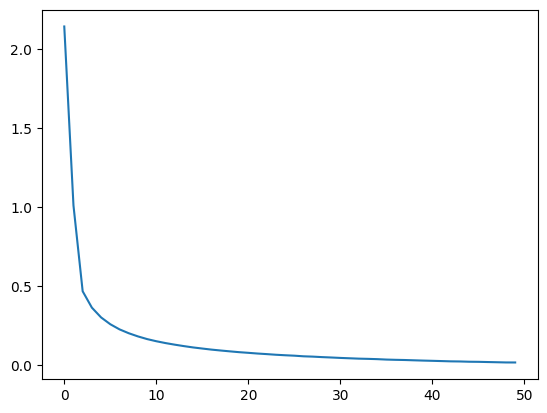

In [8]:
# Loss curve.
plt.plot(losses);

In [9]:
# Predictions over the full train and dev splits.
inp = data_loader.dataset.tensors[0]
train_preds = classifier(inp)

inp_test = test_loader.dataset.tensors[0]
test_preds = classifier(inp_test)

In [10]:
from sklearn.metrics import recall_score, accuracy_score, precision_score, f1_score, classification_report, confusion_matrix

In [11]:
# argmax turns 10 logits into a predicted class index - the multiclass
# equivalent of thresholding a single logit at 0.
train_preds = torch.argmax(train_preds, dim=1).cpu()
train_label = data_loader.dataset.tensors[1].cpu()

test_preds = torch.argmax(test_preds, dim=1).cpu()
test_label = test_loader.dataset.tensors[1].cpu()

In [12]:
# average=None returns one score PER CLASS instead of a single number.
# That is what you want first: the per-class array shows immediately whether the
# model is uniformly good or excellent-on-nine-digits-and-hopeless-on-one.
# The argument order is (y_true, y_pred) and it is NOT optional: accuracy and F1
# are symmetric, but precision and recall swap into each other if you reverse
# them. sklearn cannot detect the mistake - both arguments are just label arrays.
acc_train = accuracy_score(train_label, train_preds)
recall_train = recall_score(train_label, train_preds, average=None)
precision_train = precision_score(train_label, train_preds, average=None)
f1_train = f1_score(train_label, train_preds, average=None)

acc_test = accuracy_score(test_label, test_preds)
recall_test = recall_score(test_label, test_preds, average=None)
precision_test = precision_score(test_label, test_preds, average=None)
f1_test = f1_score(test_label, test_preds, average=None)

In [13]:
# classification_report prints all of it at once, per class, with support.
# This is the standard summary to report for a multiclass model.
print(classification_report(test_label, test_preds))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1165
           1       0.99      0.97      0.98      1387
           2       0.96      0.97      0.97      1248
           3       0.96      0.96      0.96      1197
           4       0.96      0.98      0.97      1134
           5       0.95      0.96      0.96      1119
           6       0.97      0.96      0.97      1166
           7       0.97      0.97      0.97      1188
           8       0.95      0.96      0.95      1198
           9       0.96      0.95      0.95      1198

    accuracy                           0.97     12000
   macro avg       0.97      0.97      0.97     12000
weighted avg       0.97      0.97      0.97     12000



In [14]:
# The raw labels, as a sanity check on dtype and range.
train_label

tensor([1, 5, 5,  ..., 0, 9, 1])

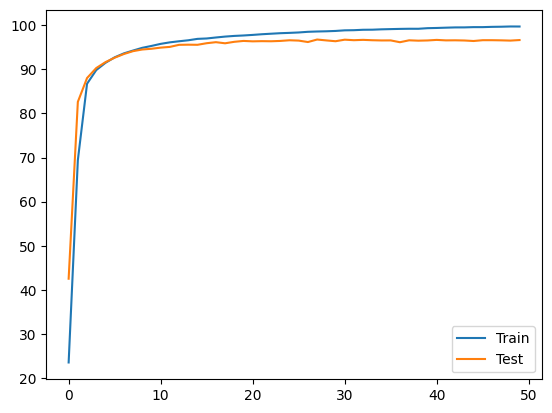

In [15]:
# Train vs dev accuracy over epochs.
plt.plot(train_acc, label="Train")
dev_acc = [i.cpu() for i in dev_acc ]
plt.plot(dev_acc, label="Test")
plt.legend(loc = 'lower right');

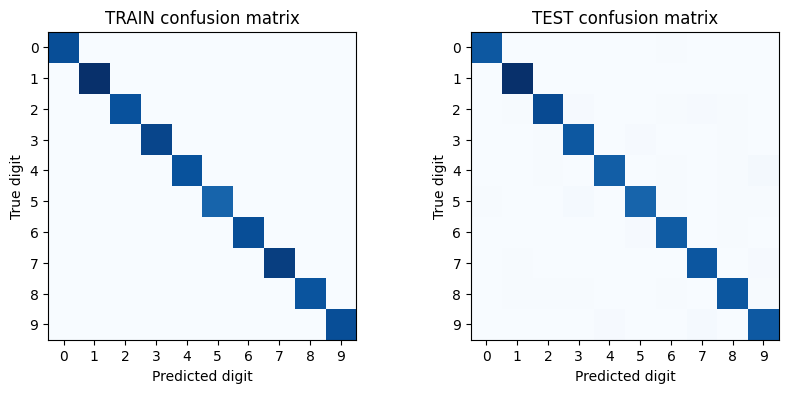

In [16]:
# The 10x10 confusion matrices. Rows are the TRUE digit, columns the PREDICTED
# one, so the diagonal is correct classifications.
# Look at the bright off-diagonal cells: those pairs are the model's actual
# problem. Expect 4 vs 9, 3 vs 5, 7 vs 1 - the digits that genuinely look alike
# once you throw away spatial structure by flattening the image.
# Confusion matrices
trainConf = confusion_matrix(data_loader.dataset.tensors[1].cpu(),train_preds)
testConf  = confusion_matrix(test_loader.dataset.tensors[1].cpu(), test_preds)

fig,ax = plt.subplots(1,2,figsize=(10,4))

# confmat during TRAIN
ax[0].imshow(trainConf,'Blues')
ax[0].set_xticks(np.arange(10))
ax[0].set_yticks(np.arange(10))
ax[0].set_xticklabels(np.arange(10))
ax[0].set_yticklabels(np.arange(10))
ax[0].set_xlabel('Predicted digit')
ax[0].set_ylabel('True digit')
ax[0].set_title('TRAIN confusion matrix')

# confmat during TEST
ax[1].imshow(testConf,'Blues')
ax[1].set_xticks(np.arange(10))
ax[1].set_yticks(np.arange(10))
ax[1].set_xticklabels(np.arange(10))
ax[1].set_yticklabels(np.arange(10))
ax[1].set_xlabel('Predicted digit')
ax[1].set_ylabel('True digit')
ax[1].set_title('TEST confusion matrix')

plt.show()